 ResNet50 — Improved Training Notebook
 Additions: Fundus Cropping + Mixup + ColorJitter

In [2]:
# ── Cell 1: Mount Drive & Imports ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/MLP')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms.functional as TF
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, cohen_kappa_score
)
from tqdm.notebook import tqdm
from PIL import Image

from dataset import APTOSDataset

Mounted at /content/drive


In [3]:
# ── Cell 2: Paths ───────────────────────────────────────────────
APTOS_CSV       = "/content/drive/MyDrive/MLP/aptos_dataset/train.csv"
APTOS_IMAGE_DIR = "/content/drive/MyDrive/MLP/aptos_dataset"

# ✅ New unique filenames for this improved run
CHECKPOINT_PATH = "/content/drive/MyDrive/MLP/dr_resnet50_checkpoint_improved.pth"
BEST_MODEL_PATH = "/content/drive/MyDrive/MLP/dr_resnet50_best_improved.pth"

os.makedirs("/content/drive/MyDrive/MLP/results", exist_ok=True)



In [4]:
# ── Cell 3: Hyperparameters ─────────────────────────────────────
NUM_EPOCHS   = 15
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-5
RANDOM_SEED  = 78
MIXUP_ALPHA  = 0.2   # Beta distribution parameter for mixup
MIXUP_PROB   = 0.5   # Probability of applying mixup to a batch


In [5]:
# ── Cell 4: Preprocessing Helpers ──────────────────────────────
class SquarePad:
    """Pads image to square before resizing, preserving aspect ratio."""
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = [hp, vp, max_wh - w - hp, max_wh - h - vp]
        return TF.pad(image, padding, fill=0, padding_mode='constant')


def crop_fundus(image):
    """
    Crops the black border around the retinal fundus image.
    Different cameras produce different border sizes — removing them
    reduces camera-specific artefacts and helps cross-domain generalisation.
    Falls back to original image if no valid contour is found.
    """
    gray = np.array(image.convert('L'))
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest)
        # Only crop if the detected region is reasonably large
        # (avoids cropping to a tiny region on dark/corrupted images)
        if w > image.size[0] * 0.5 and h > image.size[1] * 0.5:
            image = image.crop((x, y, x + w, y + h))

    return image


def make_thresholds(label):
    """Convert DR grade to ordinal threshold vector. e.g. 2 -> [1,1,0,0]"""
    return [1 if label >= i else 0 for i in range(1, 5)]


def decode_ordinal_predictions(logits):
    """Convert model logits to DR grade (0-4) via sigmoid thresholding."""
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).int()
    return preds.sum(dim=1)

print("✅ Preprocessing helpers ready")

✅ Preprocessing helpers ready


In [6]:
# ── Cell 5: Mixup Helper ────────────────────────────────────────
def mixup_batch(images, labels, alpha=0.2, prob=0.5):
    """
    Applies mixup augmentation to a batch.
    Blends pairs of images and their ordinal labels with a random
    lambda drawn from a Beta(alpha, alpha) distribution.
    Only applied with probability `prob` to preserve some clean samples.

    Args:
        images : FloatTensor [B, 3, H, W]
        labels : FloatTensor [B, 4]  — ordinal threshold vectors
        alpha  : Beta distribution parameter (higher = more mixing)
        prob   : probability of applying mixup to this batch

    Returns:
        mixed_images, mixed_labels
    """
    if torch.rand(1).item() > prob:
        return images, labels

    lam = np.random.beta(alpha, alpha)

    batch_size = images.size(0)
    index      = torch.randperm(batch_size).to(images.device)

    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_labels = lam * labels + (1 - lam) * labels[index]

    return mixed_images, mixed_labels

print("✅ Mixup helper ready")


✅ Mixup helper ready


In [7]:
# ── Cell 6: Transforms ──────────────────────────────────────────
# ✅ Added: crop_fundus (removes camera border artefacts)
# ✅ Added: ColorJitter (teaches model to be less sensitive to
#           colour/contrast differences between datasets)
# ✅ Mixup is applied in the training loop, not here

transform_train = transforms.Compose([
    transforms.Lambda(crop_fundus),          # ✅ NEW: remove black border
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(                  # ✅ NEW: colour/contrast variation
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Lambda(crop_fundus),          # ✅ NEW: same cropping at val time
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("✅ Transforms ready")


✅ Transforms ready


In [8]:
# ── Cell 7: Load & Filter Dataset ──────────────────────────────
df = pd.read_csv(APTOS_CSV)

df = df[df['id_code'].apply(
    lambda x: os.path.exists(os.path.join(APTOS_IMAGE_DIR, x + ".png"))
)].reset_index(drop=True)

print(f"Dataset size after filtering: {df.shape[0]}")

df['thresholds'] = df['diagnosis'].apply(make_thresholds)

Dataset size after filtering: 3662


In [9]:
# ── Cell 8: Train / Val Split ───────────────────────────────────
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=RANDOM_SEED
)

print(f"Train: {train_df.shape[0]}  Val: {val_df.shape[0]}")

class_counts_tr = train_df['diagnosis'].value_counts().sort_index().values
class_counts_vl = val_df['diagnosis'].value_counts().sort_index().values
print(f"Train class counts: {class_counts_tr}")
print(f"Val class counts:   {class_counts_vl}")

Train: 2929  Val: 733
Train class counts: [1444  296  799  154  236]
Val class counts:   [361  74 200  39  59]


In [10]:
# ── Cell 9: Datasets & Loaders ──────────────────────────────────
train_dataset = APTOSDataset(train_df, APTOS_IMAGE_DIR, transform_train)
val_dataset   = APTOSDataset(val_df,   APTOS_IMAGE_DIR, transform_val)

class_weights  = 1.0 / class_counts_tr
sample_weights = torch.tensor(
    train_df['diagnosis'].map(
        {i: class_weights[i] for i in range(len(class_weights))}
    ).values,
    dtype=torch.float
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

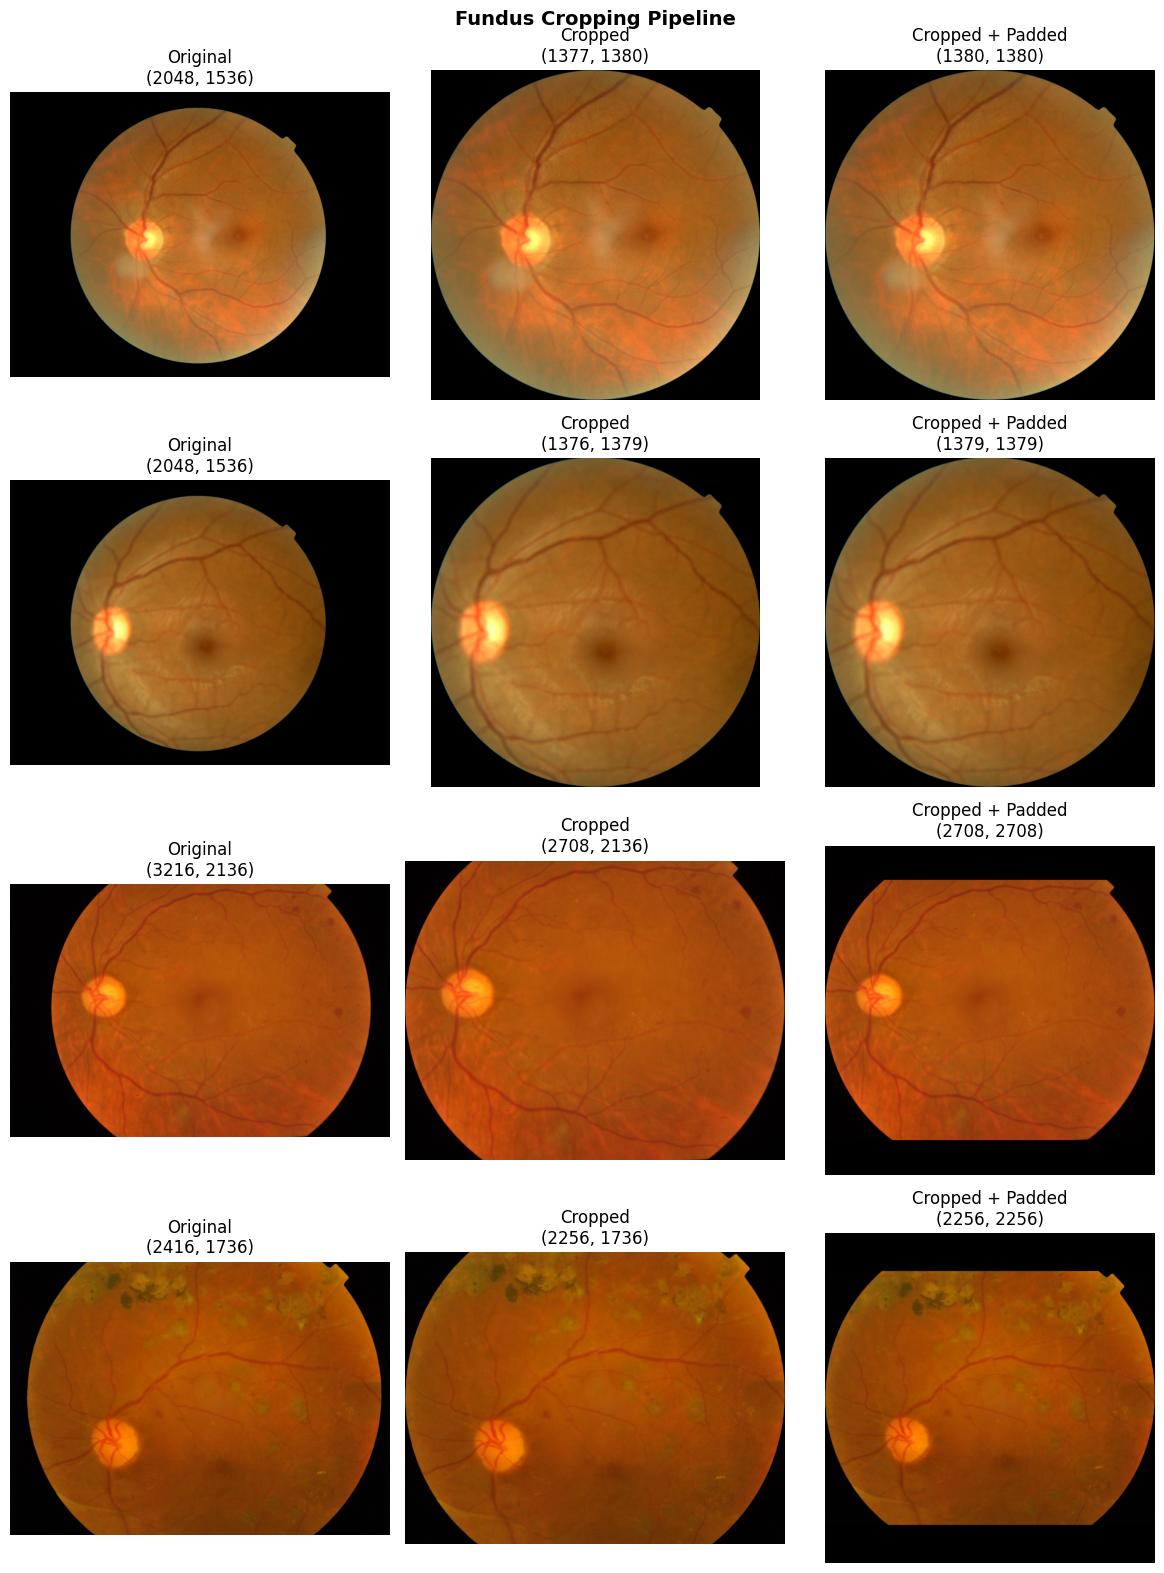

In [11]:
# ── Cell 10: Visualise Cropping Effect ──────────────────────────
# Shows before/after for a few images so you can verify cropping works
sample_images = df['id_code'].sample(4, random_state=RANDOM_SEED).values

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i, img_id in enumerate(sample_images):
    path     = os.path.join(APTOS_IMAGE_DIR, img_id + ".png")
    original = Image.open(path).convert("RGB")
    cropped  = crop_fundus(original)
    padded   = SquarePad()(cropped)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original\n{original.size}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cropped)
    axes[i, 1].set_title(f"Cropped\n{cropped.size}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(padded)
    axes[i, 2].set_title(f"Cropped + Padded\n{padded.size}")
    axes[i, 2].axis("off")

plt.suptitle("Fundus Cropping Pipeline", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32, 4])


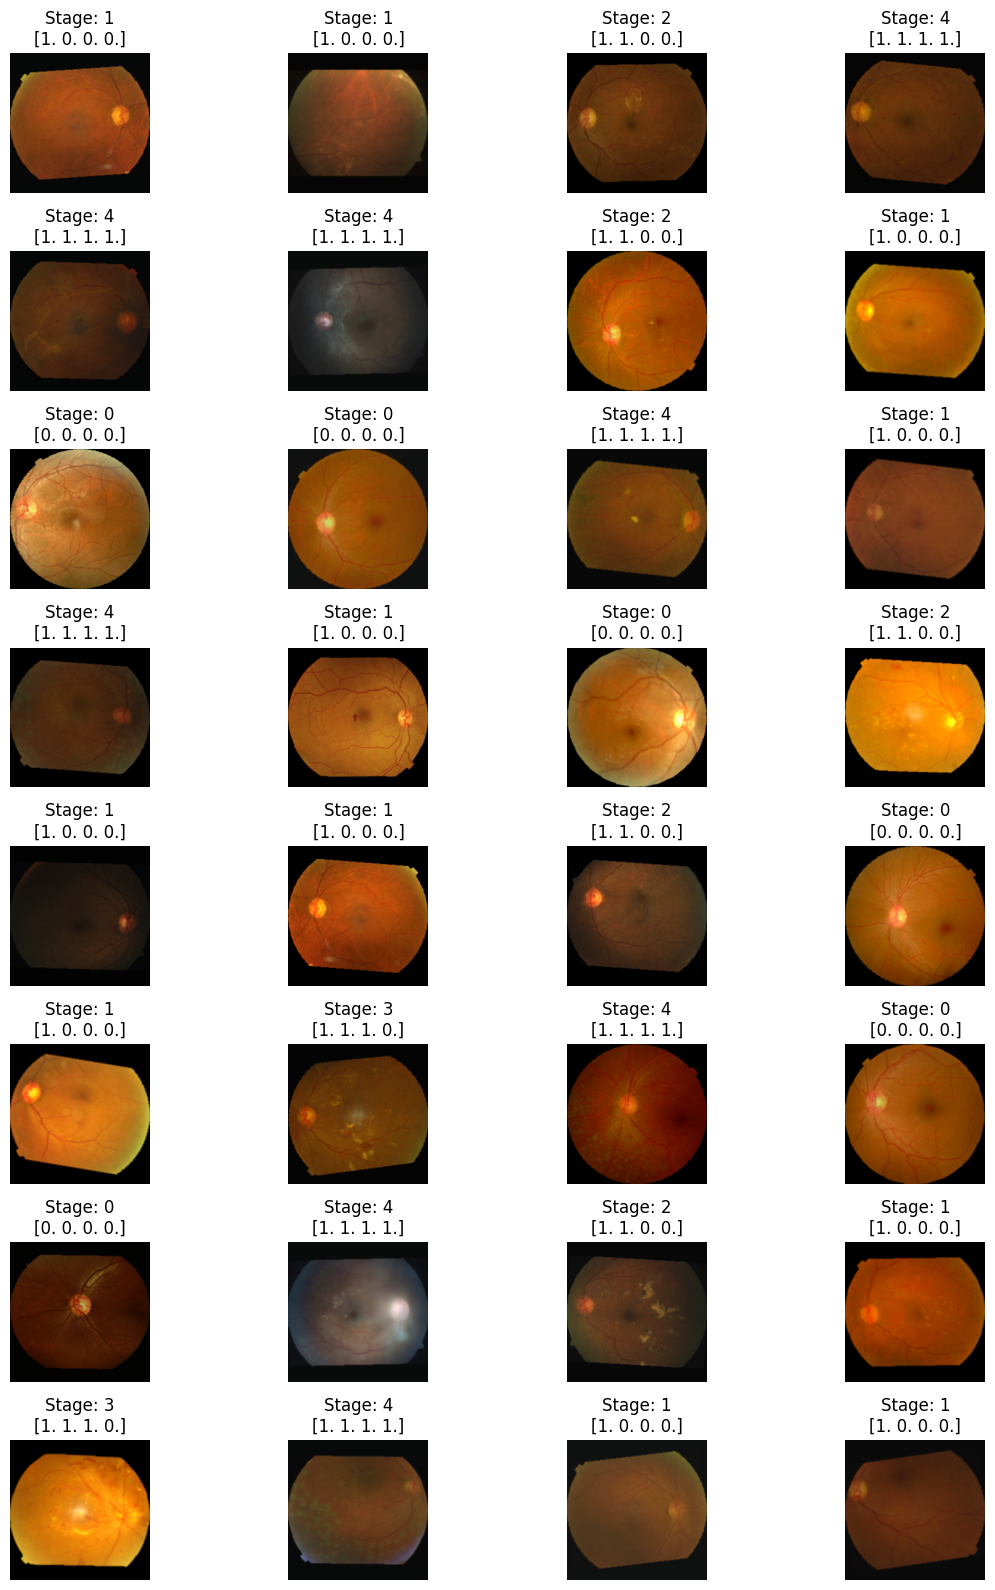

In [12]:
# ── Cell 11: Visualise a Training Batch ─────────────────────────
images, labels = next(iter(train_loader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(8, 4, figsize=(12, 16))
axes = axes.flatten()

for i in range(len(images)):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    stage = int(labels[i].cpu().numpy().sum())
    axes[i].set_title(f"Stage: {stage}\n{labels[i].cpu().numpy()}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

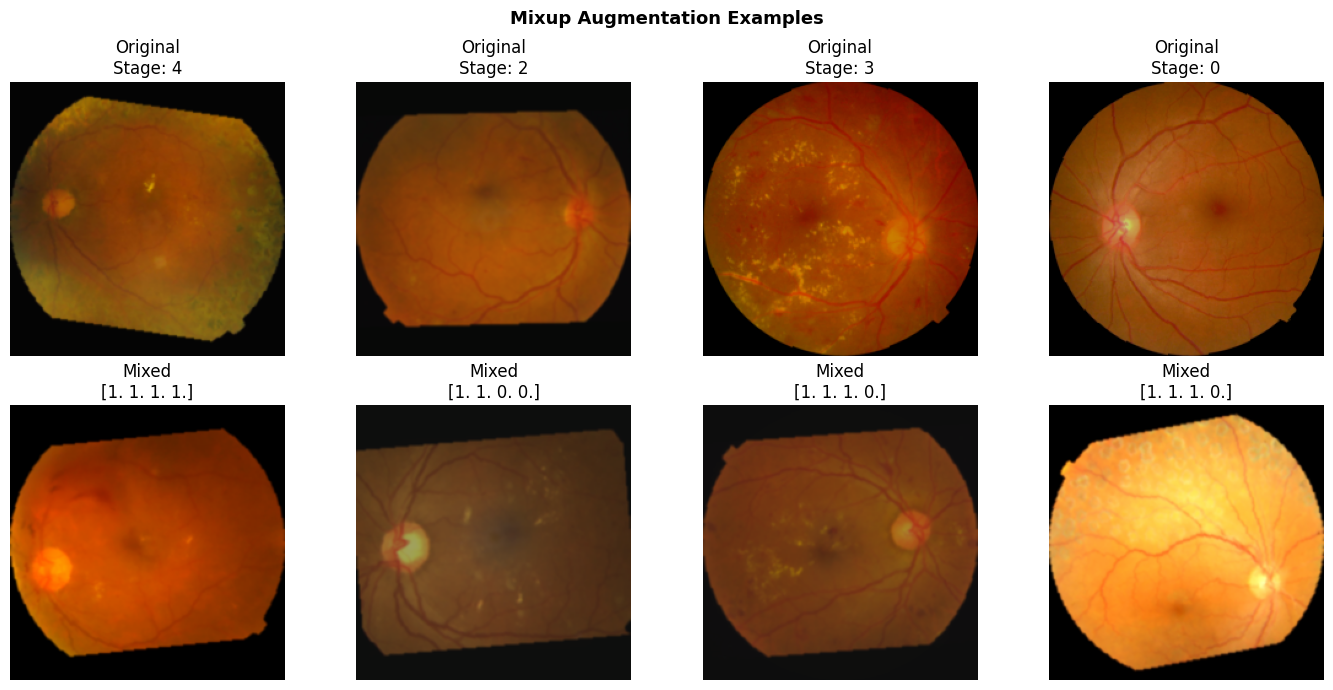

In [13]:
# ── Cell 12: Visualise Mixup ────────────────────────────────────
# Shows what mixed images look like before they go into the model
images, labels = next(iter(train_loader))
mixed_imgs, mixed_lbls = mixup_batch(images, labels, alpha=MIXUP_ALPHA, prob=1.0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i in range(4):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original\nStage: {int(labels[i].sum())}")
    axes[0, i].axis('off')

    mix = mixed_imgs[i].cpu().numpy().transpose(1, 2, 0)
    mix = std * mix + mean
    mix = np.clip(mix, 0, 1)
    axes[1, i].imshow(mix)
    axes[1, i].set_title(f"Mixed\n{mixed_lbls[i].numpy().round(2)}")
    axes[1, i].axis('off')

plt.suptitle("Mixup Augmentation Examples", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Cell 13: Build Model ─────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

weights  = ResNet50_Weights.DEFAULT
model    = resnet50(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 4)
model    = model.to(device)


Using device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


In [15]:
# ── Cell 14: Stage-Weighted Loss ────────────────────────────────
stage_counts  = train_df['diagnosis'].value_counts().sort_index()
stage_weights = 1.0 / stage_counts
stage_weights = stage_weights / stage_weights.sum()

print("Stage weights:")
print(stage_weights)

threshold_weights = torch.tensor([
    stage_weights[1:].sum(),
    stage_weights[2:].sum(),
    stage_weights[3:].sum(),
    stage_weights[4]
]).float().to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=threshold_weights)

Stage weights:
diagnosis
0    0.043139
1    0.210448
2    0.077963
3    0.404498
4    0.263952
Name: count, dtype: float64


In [16]:
# ── Cell 15: Optimizer & Scheduler ──────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)
print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


In [17]:
# ── Cell 16: Resume from Checkpoint ─────────────────────────────
# ✅ Only run this cell if resuming after a Colab disconnect.
# Skip it if starting fresh.

if os.path.exists(CHECKPOINT_PATH):
    print(f"Resuming from: {CHECKPOINT_PATH}")
    checkpoint    = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch   = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    train_losses  = checkpoint.get('train_losses', [])
    val_losses    = checkpoint.get('val_losses', [])
    print(f"Resuming from epoch {start_epoch}, best val loss: {best_val_loss:.4f}")
else:
    print("No checkpoint found — starting fresh.")
    start_epoch   = 0
    best_val_loss = float('inf')
    train_losses  = []
    val_losses    = []

Resuming from: /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_improved.pth
Resuming from epoch 15, best val loss: 0.1057


In [ ]:
# ── Cell 17: Training Loop ───────────────────────────────────────
# ✅ If starting fresh, initialise here. Comment out if running Cell 16.
# start_epoch   = 0
# best_val_loss = float('inf')
# train_losses  = []
# val_losses    = []

for epoch in range(start_epoch, NUM_EPOCHS):

    # --- Train ---
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images = images.to(device)
        labels = labels.to(device).float()

        # ✅ Apply mixup augmentation
        images, labels = mixup_batch(images, labels, alpha=MIXUP_ALPHA, prob=MIXUP_PROB)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # --- Validate ---
    # ✅ No mixup at validation time — clean evaluation
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            images = images.to(device)
            labels = labels.to(device).float()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {epoch_train_loss:.4f}")
    print(f"  Val Loss:   {epoch_val_loss:.4f}")

    scheduler.step(epoch_val_loss)

    # --- Save checkpoint ---
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss':           epoch_train_loss,
        'val_loss':             epoch_val_loss,
        'best_val_loss':        best_val_loss,
        'train_losses':         train_losses,
        'val_losses':           val_losses,
    }, CHECKPOINT_PATH)
    print(f"  Checkpoint saved → {CHECKPOINT_PATH}")

    # --- Save best model ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  ✅ Best model updated (val loss: {best_val_loss:.4f}) → {BEST_MODEL_PATH}")

print("\n🏁 Training complete!")
print(f"Best val loss achieved: {best_val_loss:.4f}")

Epoch 13/15 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 13/15 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 13/15
  Train Loss: 0.0768
  Val Loss:   0.1081
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_improved.pth


Epoch 14/15 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 14/15 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 14/15
  Train Loss: 0.1002
  Val Loss:   0.1057
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_improved.pth
  ✅ Best model updated (val loss: 0.1057) → /content/drive/MyDrive/MLP/dr_resnet50_best_improved.pth


Epoch 15/15 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 15/15 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]


Epoch 15/15
  Train Loss: 0.0921
  Val Loss:   0.1226
  Checkpoint saved → /content/drive/MyDrive/MLP/dr_resnet50_checkpoint_improved.pth

🏁 Training complete!
Best val loss achieved: 0.1057


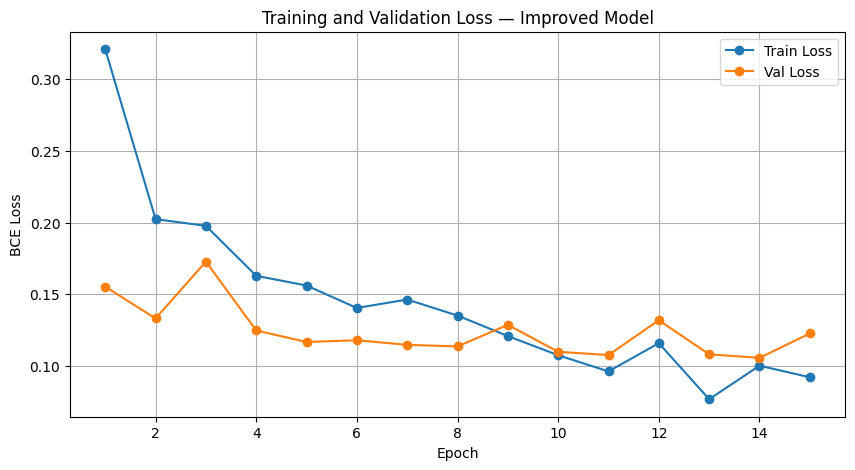

✅ Loss plot saved


In [18]:
# ── Cell 18: Loss Plot ───────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss',   marker='o')
plt.title('Training and Validation Loss — Improved Model')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True)
plt.savefig("/content/drive/MyDrive/MLP/results/loss_plot_improved.png", dpi=150)
plt.show()
print("✅ Loss plot saved")

In [19]:
# ── Cell 19: Load Best Model ─────────────────────────────────────
# ✅ Always load best checkpoint before evaluating
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()
print(f"✅ Best model loaded from {BEST_MODEL_PATH}")

✅ Best model loaded from /content/drive/MyDrive/MLP/dr_resnet50_best_improved.pth


In [20]:
# ── Cell 20: APTOS Validation Predictions ───────────────────────
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="APTOS Validation"):
        images = images.to(device)
        logits = model(images)
        preds  = decode_ordinal_predictions(logits).cpu().numpy()
        true   = labels.numpy().sum(axis=1)
        all_preds.extend(preds)
        all_labels.extend(true)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

APTOS Validation:   0%|          | 0/23 [00:00<?, ?it/s]

In [21]:
# ── Cell 21: APTOS Metrics ───────────────────────────────────────
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='macro', zero_division=0)
qwk       = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

print("APTOS Validation — Overall Metrics")
print("─" * 35)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"QWK      : {qwk:.4f}")

APTOS Validation — Overall Metrics
───────────────────────────────────
Accuracy : 0.8022
Precision: 0.6344
Recall   : 0.5948
F1 Score : 0.5908
QWK      : 0.8968


In [22]:
# ── Cell 22: Stage-Wise Accuracy ─────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

print("\nStage-wise Accuracy")
print("─" * 35)
for stage in range(5):
    correct = cm[stage, stage]
    total   = cm[stage].sum()
    acc_s   = correct / total if total > 0 else 0
    print(f"Stage {stage}: {acc_s:.4f} ({correct}/{total})")


Stage-wise Accuracy
───────────────────────────────────
Stage 0: 0.9889 (357/361)
Stage 1: 0.7297 (54/74)
Stage 2: 0.7700 (154/200)
Stage 3: 0.2821 (11/39)
Stage 4: 0.2034 (12/59)


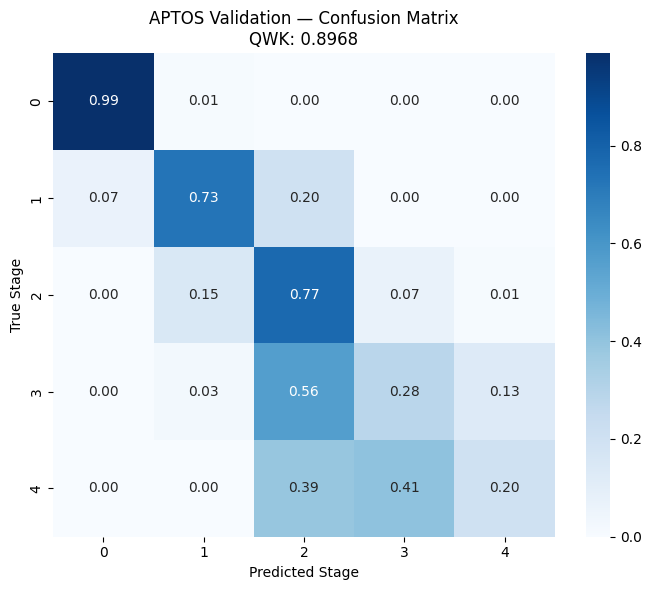

✅ Confusion matrix saved


In [23]:
# ── Cell 23: Confusion Matrix ────────────────────────────────────
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(cm_normalized, annot=True, cmap="Blues", fmt=".2f",
            xticklabels=["0","1","2","3","4"],
            yticklabels=["0","1","2","3","4"])
plt.xlabel("Predicted Stage")
plt.ylabel("True Stage")
plt.title(f"APTOS Validation — Confusion Matrix\nQWK: {qwk:.4f}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MLP/results/aptos_cm_improved.png", dpi=150)
plt.show()
print("✅ Confusion matrix saved")

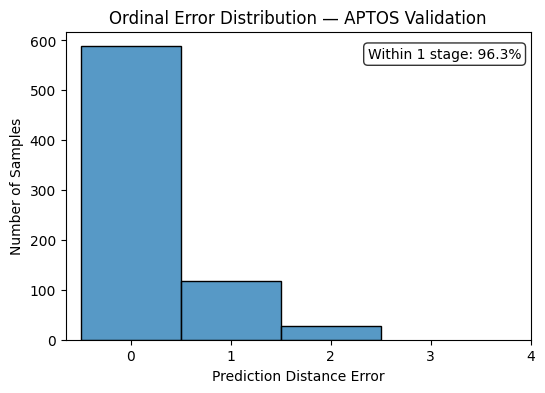

In [24]:
# ── Cell 24: Ordinal Error Distribution ─────────────────────────
errors = np.abs(all_labels - all_preds)

plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=np.arange(0, 6) - 0.5, discrete=True)
plt.xlabel("Prediction Distance Error")
plt.ylabel("Number of Samples")
plt.title("Ordinal Error Distribution — APTOS Validation")
plt.xticks(range(5))
within_1 = (errors <= 1).mean() * 100
plt.text(0.98, 0.95, f'Within 1 stage: {within_1:.1f}%',
         transform=plt.gca().transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.show()